# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


Dataset yang saya gunakan berasal dari Kaggle berupa informasi tentang artikel berita.
* title: title of the article.
* news_url: URL of the article.
* source domain: web domain where article was posted.
* tweet_num: number of retweets for this article.
* real: label column, where 1 is real and 0 is fake.

Link dataset : [Fake News](https://www.kaggle.com/datasets/algord/fake-news)

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
path = "/content/FakeNewsNet_raw.csv"
df = pd.read_csv(path)
df.head()

,title,news_url,source_domain,tweet_num,real
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42,1
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,1
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63,1
3,Colombian singer Maluma sparks rumours of inap...,https://www.dailymail.co.uk/news/article-33655...,www.dailymail.co.uk,20,1
4,Gossip Girl 10 Years Later: How Upper East Sid...,https://www.zerchoo.com/entertainment/gossip-g...,www.zerchoo.com,38,1


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [ ]:
print(df.info())
print(df.shape)
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23196 entries, 0 to 23195
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   title          23196 non-null  object
 1   news_url       22866 non-null  object
 2   source_domain  22866 non-null  object
 3   tweet_num      23196 non-null  int64 
 4   real           23196 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 906.2+ KB
None
(23196, 5)
Index(['title', 'news_url', 'source_domain', 'tweet_num', 'real'], dtype='object')


Set text_col=title and label_col=real
real
1    17441
0     5755
Name: count, dtype: int64


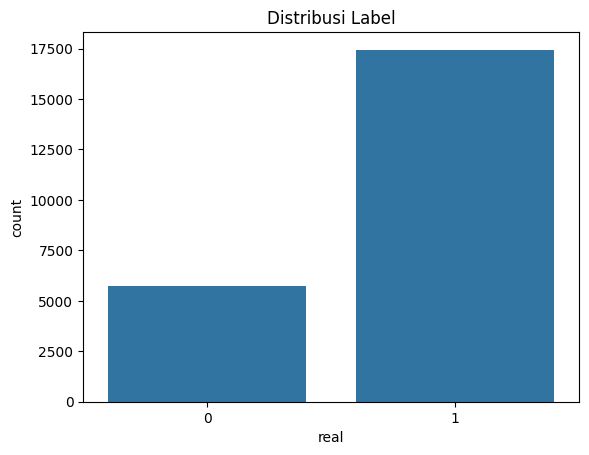

In [ ]:
# Distribusi label

text_col = 'title'
label_col = 'real'
print('Set text_col=title and label_col=real')

label_counts = df[label_col].value_counts(dropna=False)
print(label_counts)
sns.countplot(x=df[label_col])
plt.title("Distribusi Label")
plt.show()

In [ ]:
print("\nMissing values per column:")
print(df.isna().sum())


Missing values per column:
title              0
news_url         330
source_domain    330
tweet_num          0
real               0
dtype: int64


In [ ]:
print("\nData Duplicated:")
print(df.duplicated().sum())


Data Duplicated:
137


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
# Menghapus kolom yang tidak dibutuhkan
df = df.drop(columns=['news_url'])

# Mengisi missing value pada kolom source_domain
df['source_domain'] = df['source_domain'].fillna("Unknown")

# Cek ulang
print(df.isnull().sum())

title            0
source_domain    0
tweet_num        0
real             0
dtype: int64


In [ ]:
# Menghapus baris duplikat
df = df.drop_duplicates()

# Cek ulang
df.duplicated().sum()

np.int64(0)

In [ ]:
# Menyiapkan stopwords & lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # lowercase
    text = text.lower()

    # menghapus URL
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)

    # menghapus HTML tags
    text = re.sub(r'<.*?>', '', text)

    # menghapus angka
    text = re.sub(r'\d+', '', text)

    # menghapus punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # menghapus karakter non-alfabet
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # tokenize sederhana
    tokens = text.split()

    # hapus stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # gabungkan kembali
    return " ".join(tokens)

# Terapkan preprocessing ke kolom teks
df['clean_title'] = df['title'].astype(str).apply(clean_text)

# Tampilkan contoh sebelum & sesudah
print("Contoh Sebelum & Sesudah Cleaning")
for i in range(3):
    print("\nOriginal:", df['title'].iloc[i])
    print("Cleaned :", df['clean_title'].iloc[i])

Contoh Sebelum & Sesudah Cleaning

Original: Kandi Burruss Explodes Over Rape Accusation on 'Real Housewives of Atlanta' Reunion (Video)
Cleaned : kandi burruss explodes rape accusation real housewife atlanta reunion video

Original: People's Choice Awards 2018: The best red carpet looks
Cleaned : people choice award best red carpet look

Original: Sophia Bush Sends Sweet Birthday Message to 'One Tree Hill' Co-Star Hilarie Burton: 'Breyton 4eva'
Cleaned : sophia bush sends sweet birthday message one tree hill costar hilarie burton breyton eva


In [ ]:
df.head()

,title,source_domain,tweet_num,real,clean_title
0,Kandi Burruss Explodes Over Rape Accusation on...,toofab.com,42,1,kandi burruss explodes rape accusation real ho...
1,People's Choice Awards 2018: The best red carp...,www.today.com,0,1,people choice award best red carpet look
2,Sophia Bush Sends Sweet Birthday Message to 'O...,www.etonline.com,63,1,sophia bush sends sweet birthday message one t...
3,Colombian singer Maluma sparks rumours of inap...,www.dailymail.co.uk,20,1,colombian singer maluma spark rumour inappropr...
4,Gossip Girl 10 Years Later: How Upper East Sid...,www.zerchoo.com,38,1,gossip girl year later upper east siders shock...


In [ ]:
df.to_csv("/content/FakeNewsNet_preprocessing.csv", index=False)